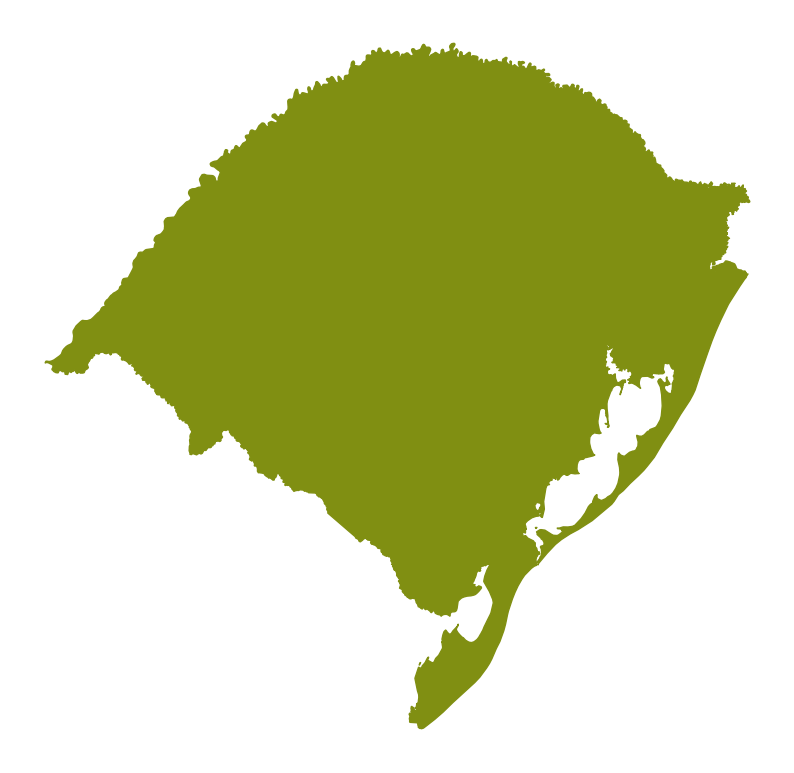

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# carregar os dados dos estados brasileiros diretamente de uma fonte online
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url)

# filtra apenas o estado do Rio Grande do Sul
rs_mapa = brasil[brasil['sigla'] == 'RS']

fig, ax = plt.subplots(figsize=(10, 10))

rs_mapa.plot(ax=ax, facecolor='#808f12', edgecolor='#808f12', linewidth=1)

ax.axis('off')
plt.show()

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import glob


arquivos = glob.glob("dados_*.csv")
lista_estacoes = []

for arquivo in arquivos:
    try:
        # Extrai Latitude/Longitude das linhas 0-10)
        meta = {'lat': None, 'lon': None, 'nome': 'Desconhecida'}
        with open(arquivo, 'r', encoding='latin1') as f:
            for _ in range(12):
                linha = next(f)
                if 'Nome:' in linha: meta['nome'] = linha.split(':')[1].strip()
                if 'Latitude:' in linha: meta['lat'] = float(linha.split(':')[1].replace(',', '.'))
                if 'Longitude:' in linha: meta['lon'] = float(linha.split(':')[1].replace(',', '.'))

        # Lê os dados de Chuva (Corpo do arquivo)
        df_temp = pd.read_csv(arquivo, sep=';', skiprows=10, encoding='latin1', decimal=',', engine='python')

        # Encontra a coluna de chuva
        col_chuva = [c for c in df_temp.columns if 'PRECIPITACAO' in c]

        if col_chuva and meta['lat'] is not None:
            nome_col = col_chuva[0]
            # Soma a chuva total
            total_chuva = df_temp[nome_col].fillna(0).sum()

            # Adiciona na lista final para o mapa
            lista_estacoes.append({
                'Nome': meta['nome'],
                'Latitude': meta['lat'],
                'Longitude': meta['lon'],
                'Chuva': total_chuva
            })

    except Exception as e:
        print(f"Pulei {arquivo}: {e}")

# Cria o DataFrame que TEM as colunas Latitude e Longitude
df_estacoes = pd.DataFrame(lista_estacoes)

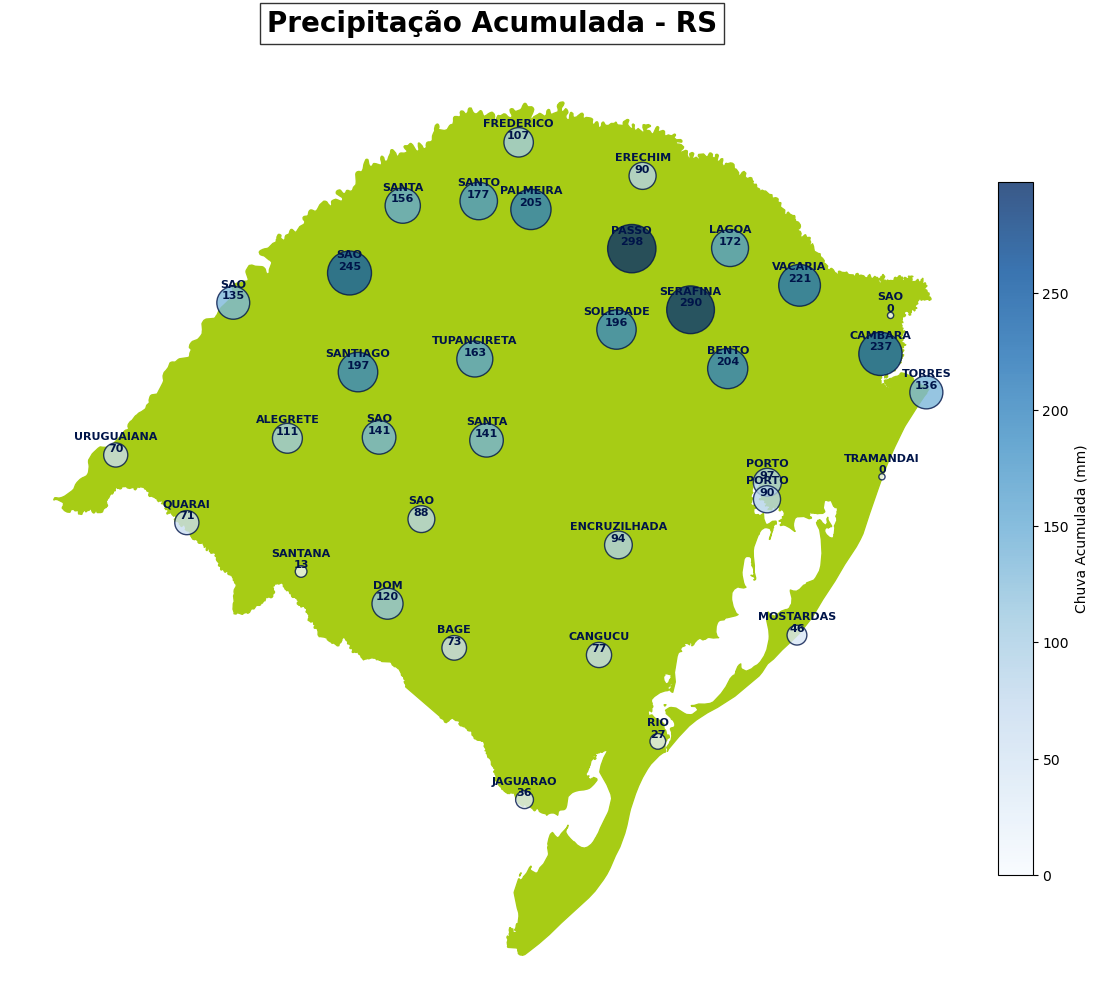

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url)

rs_mapa = brasil[brasil['sigla'] == 'RS']

fig, ax = plt.subplots(figsize=(15, 15))

rs_mapa.plot(ax=ax, facecolor='#a7cc15', edgecolor='#a7cc15', linewidth=1)

# Desenha as BOLOTAS (Usando df_estacoes, que garantimos ter Latitude/Longitude)
if not df_estacoes.empty:
    bolotas = ax.scatter(
        df_estacoes['Longitude'],
        df_estacoes['Latitude'],
        s=df_estacoes['Chuva'] * 4 + 20,
        c=df_estacoes['Chuva'],
        cmap='Blues',
        alpha=0.8,
        edgecolors='#001449',
    )

    # Legendas e Títulos
    plt.colorbar(bolotas, ax=ax, shrink=0.6, label='Chuva Acumulada (mm)', pad=0.02)

    # iterrows() permite passar por cada linha da tabela individualmente
    for _, row in df_estacoes.iterrows():
        ax.text(
            row['Longitude'],        # Posição X: Mesma longitude da cidade
            row['Latitude'] + 0.03,  # Posição Y: Latitude + deslocamento para o texto flutuar acima do ponto
            f"{row['Nome'].split()[0]}\n{row['Chuva']:.0f}",  # Pega só a 1ª palavra do nome e o valor da chuva sem casas decimais
            fontsize=8, ha='center', fontweight='bold', color='#001449'
        )

ax.set_title(
    'Precipitação Acumulada - RS',
    fontsize=20, fontweight='bold',
    bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 5},
    pad=20
)

ax.axis('off')
plt.show()

In [4]:

if 'df_estacoes' in locals() and not df_estacoes.empty:

    # Seleciona apenas as colunas de Nome e Chuva
    tabela_legenda = df_estacoes[['Nome', 'Chuva']].copy()

    # Ordena da maior chuva para a menor
    tabela_legenda = tabela_legenda.sort_values(by='Chuva', ascending=False)

    # Renomeia as colunas
    tabela_legenda.columns = ['Cidade / Estação', 'Precipitação Acumulada (mm)']

    # Reseta o índice para começar de 1, 2, 3...
    tabela_legenda = tabela_legenda.reset_index(drop=True)
    tabela_legenda.index += 1 #pega valor atual e soma mais um (+=)

    print("\nTabela de Precipitação por Cidade (Set/2023)")
    display(tabela_legenda)

else:
    print("O DataFrame 'df_estacoes' não foi encontrado.")


Tabela de Precipitação por Cidade (Set/2023)


,Cidade / Estação,Precipitação Acumulada (mm)
1,PASSO FUNDO,297.8
2,SERAFINA CORREA,290.2
3,SAO LUIZ GONZAGA,245.4
4,CAMBARA DO SUL,237.4
5,VACARIA,220.6
6,PALMEIRA DAS MISSOES,205.0
7,BENTO GONCALVES,203.8
8,SANTIAGO,197.2
9,SOLEDADE,196.0
10,SANTO AUGUSTO,176.8
